## Business forecasting final project


In [1]:
import operator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mlforecast import MLForecast
from mlforecast.lag_transforms import Combine, RollingMean
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

from utilsforecast.evaluation import evaluate
import utilsforecast.losses as ufl

## Part 1. Data preparation
### 1. Reading data, rename column, check missing data, transform to date time
#Loading data
future_values = pd.read_csv('future_values.csv', parse_dates=['date']).rename(
    columns={'date': 'ds', 'store_id': 'unique_id'})
metadata = pd.read_csv('metadata.csv').rename(columns={'store_id': 'unique_id'})
sales_data = pd.read_csv('sales_data.csv', parse_dates=['date']).rename(
    columns={'date': 'ds', 'store_id': 'unique_id', 'sales': 'y'})
sales_data.dtypes

C:\Users\pc\AppData\Local\Temp\ipykernel_28772\1841298493.py:22: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_data = pd.read_csv('sales_data.csv', parse_dates=['date']).rename(


unique_id                 object
ds                datetime64[ns]
y                          int64
customers                  int64
open                       int64
promo                      int64
state_holiday             object
school_holiday             int64
dtype: object

In [40]:
#Checking implicitly missing values

# Grouping data by each time series
grouped = sales_data.groupby('unique_id')

print("\nDate range per unique_id:")
date_range = sales_data.groupby('unique_id')['ds'].agg(['min', 'max', 'count'])
print(date_range)


Date range per unique_id:
                 min        max  count
unique_id                             
store_1   2013-01-07 2015-07-19    924
store_10  2013-01-07 2015-07-19    924
store_100 2013-01-07 2015-07-19    924
store_101 2013-01-07 2015-07-19    924
store_102 2013-01-07 2015-07-19    924
...              ...        ...    ...
store_95  2013-01-07 2015-07-19    924
store_96  2013-01-07 2015-07-19    924
store_97  2013-01-07 2015-07-19    924
store_98  2013-01-07 2015-07-19    924
store_99  2013-01-07 2015-07-19    924

[676 rows x 3 columns]


In [41]:
# Creating a summary dataframe for visualizing data completeness
summary = grouped.agg(
    count_observed=('ds', 'count'),
    start_date=('ds', 'min'),
    end_date=('ds', 'max')
).reset_index()

summary['expected_count'] = (
        (summary['end_date'].dt.to_period('M') - summary['start_date'].dt.to_period('M')).apply(lambda x: x.n) + 1
)

# Identifying which time series are irregular
summary['is_irregular'] = summary['count_observed'] < summary['expected_count']

filtered = summary[summary['is_irregular'] == True]
display(filtered)
##### As the result shows an empty df, there is no implicitly missing date
# Grouping data by each time series
grouped = future_values.groupby('unique_id')
summary = grouped.agg(
    count_observed=('ds', 'count'),
    start_date=('ds', 'min'),
    end_date=('ds', 'max')
).reset_index()
print(summary)

,unique_id,count_observed,start_date,end_date,expected_count,is_irregular


     unique_id  count_observed start_date   end_date
0      store_1              60 2015-07-20 2015-09-17
1     store_10              60 2015-07-20 2015-09-17
2    store_100              60 2015-07-20 2015-09-17
3    store_101              60 2015-07-20 2015-09-17
4    store_102              60 2015-07-20 2015-09-17
..         ...             ...        ...        ...
671   store_95              60 2015-07-20 2015-09-17
672   store_96              60 2015-07-20 2015-09-17
673   store_97              60 2015-07-20 2015-09-17
674   store_98              60 2015-07-20 2015-09-17
675   store_99              60 2015-07-20 2015-09-17

[676 rows x 4 columns]


In [42]:
#Checking NA
future_values.isna().sum()
metadata.isna().sum()
sales_data.isna().sum()

unique_id         0
ds                0
y                 0
customers         0
open              0
promo             0
state_holiday     0
school_holiday    0
dtype: int64

##### There is no explicitly missing value

### 2. Merge the 'metadata' with 'sales_data' and 'future_values'

In [2]:
sales_merged = pd.merge(sales_data, metadata, on='unique_id', how='left')
sales_merged['competition_distance'] = sales_merged['competition_distance'].fillna(sales_merged['competition_distance'].median())
future_merged = pd.merge(future_values, metadata, on='unique_id', how='left')
sales_merged.head()

,unique_id,ds,y,customers,open,promo,state_holiday,school_holiday,store_type,assortment,competition_distance
0,store_1,2015-07-19,0,0,0,0,0,0,c,a,1270.0
1,store_2,2015-07-19,0,0,0,0,0,0,a,a,14130.0
2,store_3,2015-07-19,0,0,0,0,0,0,a,c,24000.0
3,store_4,2015-07-19,0,0,0,0,0,0,a,a,7520.0
4,store_5,2015-07-19,0,0,0,0,0,0,a,c,2030.0


##### No 'customer' data in the 'future_values', if we need to use it for the forecasting, we need to predict the future value of 'customer' first. And if we use a predicted value to forecast the future sales, it must affect the accuracy. So it's better to delete it.

### 3. Transform to weekly data, because the company is interested in weekly forecast to make the plan for weekly inventory and staffing

In [3]:
# Create a weekly bucket：start from Monday，because the database starts with Tuesday(2013/1/1),to make the date format aligned, the first week is not a complete week, so it will be ignored.
sales_merged['week'] = sales_merged['ds'] - pd.to_timedelta(sales_merged['ds'].dt.dayofweek, unit='D')

# Make sure state_holiday is string type
sales_merged['state_holiday'] = sales_merged['state_holiday'].astype(str)

# Count how many times each state_holiday type appears per week per store
holiday_counts = (
    sales_merged
    .groupby(['unique_id', 'week', 'state_holiday'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename_axis(None, axis=1)
)

# rename as state_holiday_a,b,c
holiday_counts.columns = ['unique_id', 'week'] + [f'state_holiday_{col}' for col in holiday_counts.columns[2:]]

# Aggregate weekly data
weekly_cal = sales_merged.groupby(['unique_id', 'week'], as_index=False).agg({
    'y': 'sum',
    'customers': 'sum',
    'promo': 'mean',
    'open': 'mean',
    'school_holiday': 'mean',
    'store_type': 'first',
    'assortment': 'first',
    'competition_distance': 'first'
})

# Merge the holiday counts in
weekly_cal = weekly_cal.merge(holiday_counts, on=['unique_id', 'week'], how='left')
weekly_cal.fillna(0, inplace=True)

# Only keep store_1 to store_99,  drop 'customer' and 'state_holiday_0'
weekly_cal = weekly_cal.rename(columns={'week': 'ds'})
weekly_data = weekly_cal.copy()
weekly_data = weekly_data[weekly_data['unique_id'].isin([f'store_{i}' for i in range(1, 100)])]
weekly_data = weekly_data.drop(columns=['customers', 'state_holiday_0'])


print(weekly_data.head())

  unique_id         ds      y     promo      open  school_holiday store_type  \
0   store_1 2013-01-07  32952  0.714286  0.857143        0.714286          c   
1   store_1 2013-01-14  25978  0.000000  0.857143        0.000000          c   
2   store_1 2013-01-21  33071  0.714286  0.857143        0.000000          c   
3   store_1 2013-01-28  28693  0.000000  0.857143        0.000000          c   
4   store_1 2013-02-04  35771  0.714286  0.857143        0.000000          c   

  assortment  competition_distance  state_holiday_a  state_holiday_b  \
0          a                1270.0                0                0   
1          a                1270.0                0                0   
2          a                1270.0                0                0   
3          a                1270.0                0                0   
4          a                1270.0                0                0   

   state_holiday_c  
0                0  
1                0  
2                0  
3 

In [14]:
# same process for future_values
future_merged['week'] = future_merged['ds'] - pd.to_timedelta(future_merged['ds'].dt.dayofweek, unit='D')

# No state_holiday information, it's not necessary to count state_holiday

# Aggregate the normal weekly data
weekly_calcu = future_merged.groupby(['unique_id', 'week'], as_index=False).agg({
    'promo': 'mean',  # Ratio can better reflect the intensity of the promotion
    'open': 'mean',   #Percentage of days open per week
    'school_holiday': 'mean',  #Proportion of school holidays in the week
    'state_holiday': 'sum',
    'store_type': 'first',
    'assortment': 'first',
    'competition_distance': 'first'
})

print(weekly_calcu['state_holiday'].unique())


[0]


There are no state holidays in the 8 weeks to be predicted. In order to align with the data format of weekly_data, three new columns state_holiday a, b, c will be added and all filled with 0.

In [15]:
# Fill in 0 where a holiday type didn’t occur that week
weekly_calcu = weekly_calcu.drop('state_holiday', axis=1)
weekly_calcu['state_holiday_a'] = 0
weekly_calcu['state_holiday_b'] = 0
weekly_calcu['state_holiday_c'] = 0

weekly_calcu = weekly_calcu.rename(columns={'week': 'ds'})

weekly_future = weekly_calcu.copy()

# Only keep store_1 to store_99
weekly_future = weekly_future[weekly_future['unique_id'].isin([f'store_{i}' for i in range(1, 100)])]

weekly_future

,unique_id,ds,promo,open,school_holiday,store_type,assortment,competition_distance,state_holiday_a,state_holiday_b,state_holiday_c
0,store_1,2015-07-20,0.000000,0.857143,0.0,c,a,1270.0,0,0,0
1,store_1,2015-07-27,0.714286,0.857143,1.0,c,a,1270.0,0,0,0
2,store_1,2015-08-03,0.714286,0.857143,1.0,c,a,1270.0,0,0,0
3,store_1,2015-08-10,0.000000,0.857143,1.0,c,a,1270.0,0,0,0
4,store_1,2015-08-17,0.714286,0.857143,1.0,c,a,1270.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6079,store_99,2015-08-17,0.714286,0.857143,0.0,a,a,2640.0,0,0,0
6080,store_99,2015-08-24,0.000000,0.857143,0.0,a,a,2640.0,0,0,0
6081,store_99,2015-08-31,0.714286,0.857143,0.0,a,a,2640.0,0,0,0
6082,store_99,2015-09-07,0.000000,0.857143,0.0,a,a,2640.0,0,0,0


By tranforming to ratio, it's better for the tree model (Random Forest/LSTM) to use directly continuous features

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 只保留用于检测共线性的变量
X_vif = weekly_data[['open', 'school_holiday', 'state_holiday_0']].copy()

# 添加常数项（Intercept）
X_vif = add_constant(X_vif)

# 计算 VIF
vif_result = pd.DataFrame()
vif_result["feature"] = X_vif.columns
vif_result["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_result)

All VIFs < 2, indicating that there is almost no multicollinearity between these variables, and all can be retained for subsequent modeling.

## Part 2. Exploratory Data Analysis

### Analyze trends, seasonality, holidays, promotion, and store type impact

In [16]:
# seasonality calculation
def compute_seasonality_strength(df):
    results = []

    for uid, group in df.groupby('unique_id'):
        # 确保按时间顺序排列
        group = group.sort_values('ds')

        # 提取目标值
        y = group['y'].values

        # 以“周”作为季节单位，提取 week number (1-52)
        group['week_of_year'] = group['ds'].dt.isocalendar().week

        # 计算每个 week_of_year 的平均值（即“季节成分”）
        seasonal_means = group.groupby('week_of_year')['y'].transform('mean')

        # 残差 = y - 季节均值
        residual = y - seasonal_means.values

        # 强度计算
        var_y = np.var(y)
        var_resid = np.var(residual)
        strength = max(0, 1 - var_resid / var_y) if var_y > 0 else 0

        # 写入结果
        group['seasonality'] = strength
        results.append(group[['unique_id', 'ds', 'seasonality']])

        # 拼接前先删除旧的 seasonality 列（如存在）
        df = df.drop(columns=['seasonality'], errors='ignore')

    # 合并所有 unique_id 的结果
    return pd.merge(df, pd.concat(results), on=['unique_id', 'ds'], how='left')


# 应用函数
weekly_data = compute_seasonality_strength(weekly_data)

# 创建 store_features 表：每个 unique_id 只保留一行（避免重复）
store_features = weekly_data[[
    'unique_id', 'seasonality', 'store_type', 'assortment', 'competition_distance'
]].drop_duplicates(subset='unique_id').reset_index(drop=True)

store_features

,unique_id,seasonality,store_type,assortment,competition_distance
0,store_1,0.685406,c,a,1270.0
1,store_10,0.645521,d,c,4110.0
2,store_11,0.648266,a,c,3270.0
3,store_12,0.626657,a,c,3240.0
4,store_13,0.598713,c,c,550.0
...,...,...,...,...,...
94,store_95,0.752404,a,c,100.0
95,store_96,0.691809,a,a,12540.0
96,store_97,0.443357,d,a,980.0
97,store_98,0.606215,a,a,1070.0


季节性强度是历史数据的统计量，未来预测期无法获取该值，强行加入会导致数据泄露。按强度分组，为不同组选择不同模型（而非作为特征）

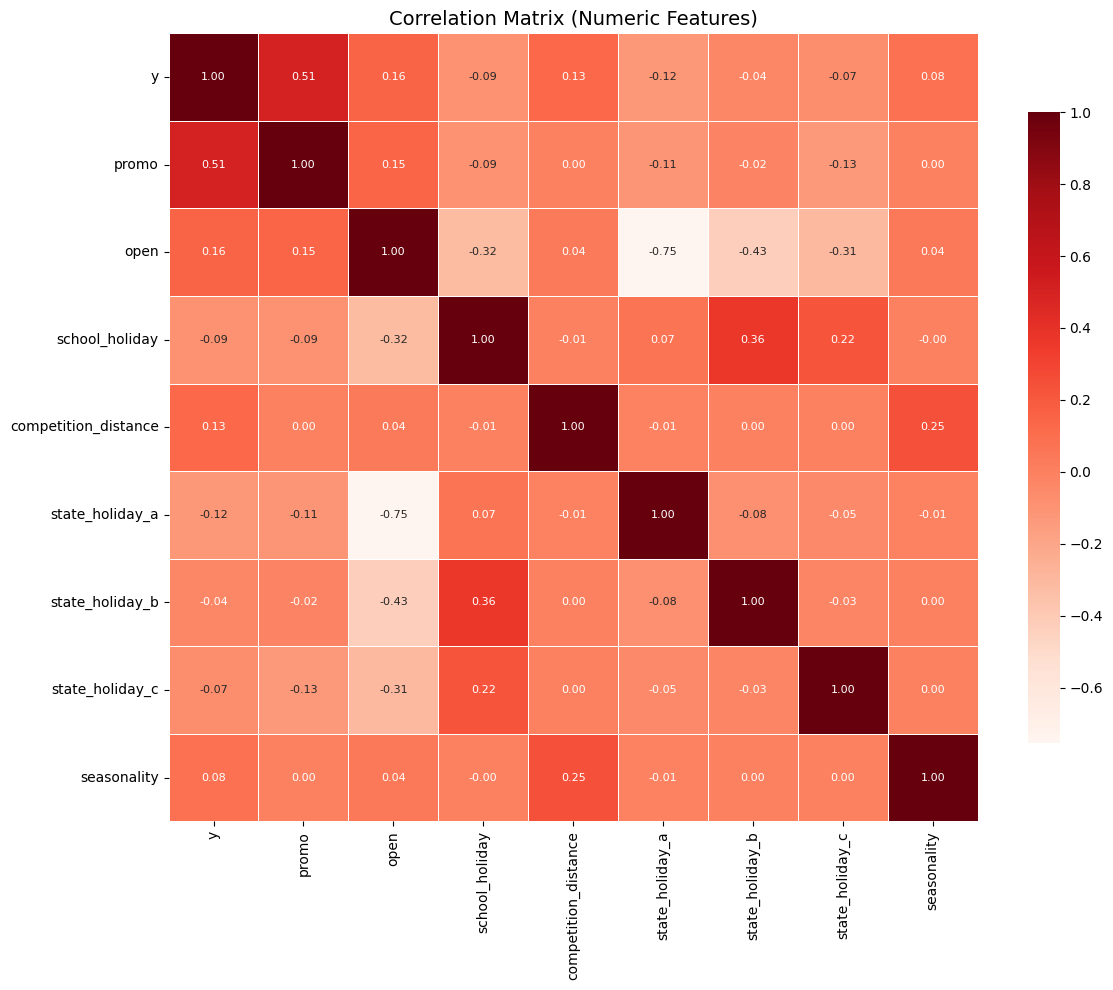

In [17]:
#correlation plot

# the value of 'open','promo','school_holiday' are ratio, between 0-1, however Holidays are discrete events, so counting is more straightforward. For example, "Christmas holiday 2 days" is easier to explain than "Christmas holiday ratio 0.28". 'state_holiday' is a counting value, in order to calculate the correlation and get a better explanation, we should choose 'spearman' method. The calculation method of spearman is based on the covariance of the ranking values.
co_mtx = weekly_data.corr(method='spearman', numeric_only=True)

# Set the size
plt.figure(figsize=(12, 10))

# Use "Reds"
sns.heatmap(
    co_mtx,
    cmap="Reds",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8}
)

# set title
plt.title("Correlation Matrix (Numeric Features)", fontsize=14)

# Prevent label overlap
plt.tight_layout()

plt.show()

##### We have used ChatGPT to improve the correlation matrix format and the interaction test part.

In [18]:
# Interaction test: promo-store_type, to see if the effect of promo is different for various type of stores
import statsmodels.formula.api as smf

# Only take necessary data
subset = weekly_data.dropna(subset=['y', 'promo', 'store_type'])

# Interaction term
model = smf.ols(formula='y ~ promo * store_type', data=subset).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     807.2
Date:                Sun, 20 Jul 2025   Prob (F-statistic):               0.00
Time:                        21:43:31   Log-Likelihood:            -1.4031e+05
No. Observations:               13068   AIC:                         2.806e+05
Df Residuals:                   13062   BIC:                         2.807e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              3.242e+

The result shows, the b - type store sales is the highest, followed by a - type store, third is d - type, and the last one is c - type. Promo significantly boosts sales and has a sales boosting effect on all four types of stores.The interaction term is not significant(all p values are > 0.1), indicating that promotion has similar effects on different types of stores.So when analyzing the relationship between 'promo' and 'sales', there is no need to analyze them separately by store type.

# interaction test for store_type 与 assortment 对销售额的交互作用

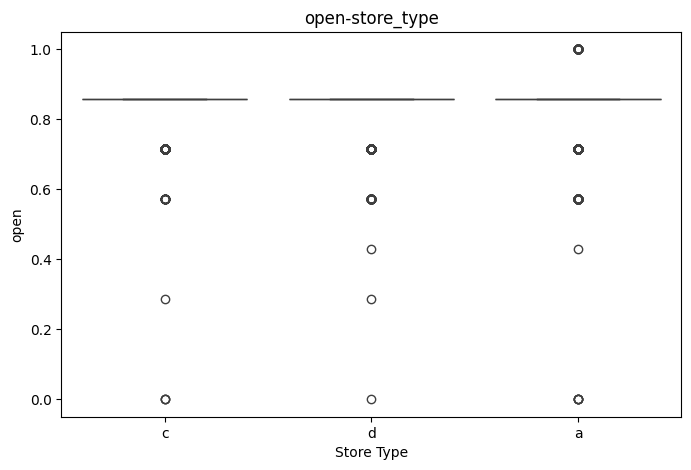

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     15.88
Date:                Sun, 20 Jul 2025   Prob (F-statistic):           1.25e-15
Time:                        21:43:37   Log-Likelihood:            -1.4203e+05
No. Observations:               13068   AIC:                         2.841e+05
Df Residuals:                   13062   BIC:                         2.841e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [19]:
# the relationship between store_type and competition_distance

plt.figure(figsize=(8, 5))
sns.boxplot(x='store_type', y='open', data=weekly_data)
plt.title("open-store_type")
plt.ylabel("open")
plt.xlabel("Store Type")
plt.show()

subset_2 = weekly_data.dropna(subset=['y', 'state_holiday_b', 'store_type'])

# Interaction term
model_2 = smf.ols(formula='y ~ state_holiday_b * store_type', data=subset_2).fit()

print(model_2.summary())
# def add_lags(weekly_data, lags):
#     for lag in lags:
#         weekly_data[f"lag_{lag}"] = weekly_data.groupby("unique_id")["y"].shift(lag)
#     return weekly_data
#
# # 添加滞后特征
# weekly_data = add_lags(weekly_data, lags=[1, 2, 4, 13, 52])
#
# # 只删除所有 lag 特征中包含 NaN 的行
# lag_cols = [f"lag_{lag}" for lag in [1, 2, 4, 13, 52]]
# weekly_data.dropna(subset=lag_cols, inplace=True)
# weekly_data
# # Step 1: Extract lag columns
# lag_cols = [col for col in weekly_data.columns if col.startswith("lag_")]
#
# # Step 2: Extract numeric feature columns (excluding id, week, y, and lag columns)
# excluded_cols = ['unique_id', 'week', 'y'] + lag_cols
# feature_cols = [col for col in weekly_data.columns
#                 if col not in excluded_cols and pd.api.types.is_numeric_dtype(weekly_data[col])]
#
# # Step 3: Initialize correlation matrix
# correlation_matrix = pd.DataFrame(index=feature_cols, columns=lag_cols, dtype=float)
#
# # Step 4: Compute correlation if both columns have variance and are not all-NaN
# for feature in feature_cols:
#     for lag in lag_cols:
#         x = weekly_data[feature]
#         y = weekly_data[lag]
#         # 检查是否有有效值和非恒定值
#         if x.nunique(dropna=True) > 1 and y.nunique(dropna=True) > 1:
#             correlation = x.corr(y)
#         else:
#             correlation = np.nan  # 无法计算相关性
#         correlation_matrix.loc[feature, lag] = correlation
#
# # Step 5: Drop rows/cols with all NaN
# correlation_matrix.dropna(how='all', axis=0, inplace=True)
# correlation_matrix.dropna(how='all', axis=1, inplace=True)
#
# # Step 6: Plot heatmap
# plt.figure(figsize=(12, 8))  # 放大图表
# sns.heatmap(correlation_matrix, annot=True, cmap="Reds", center=0,
#             fmt=".2f", annot_kws={"size": 8})
# plt.title("Correlation between Lag Features and Other Predictors")
# plt.xlabel("Lag Features")
# plt.ylabel("Other Features")
# plt.tight_layout()
# plt.show()
#### think about: open, state_holiday 0,a,b,c???????


## Part 3. Best performing model selection


#### 1. Cross validation for Naive, RWD, Seasonal Naive, Holt-Winters, AutoARIMA,Random Forest, LSTM

In [20]:
# Add is_closed_week, if the store is closed for the whole week（== 1）, the y will be 0 in the forecasting
weekly_data['is_closed_week'] = (weekly_data['open'] == 0).astype(int)
weekly_future['is_closed_week'] = (weekly_future['open'] == 0).astype(int)

print(weekly_data.head())


  unique_id         ds      y     promo      open  school_holiday store_type  \
0   store_1 2013-01-07  32952  0.714286  0.857143        0.714286          c   
1   store_1 2013-01-14  25978  0.000000  0.857143        0.000000          c   
2   store_1 2013-01-21  33071  0.714286  0.857143        0.000000          c   
3   store_1 2013-01-28  28693  0.000000  0.857143        0.000000          c   
4   store_1 2013-02-04  35771  0.714286  0.857143        0.000000          c   

  assortment  competition_distance  state_holiday_a  state_holiday_b  \
0          a                1270.0                0                0   
1          a                1270.0                0                0   
2          a                1270.0                0                0   
3          a                1270.0                0                0   
4          a                1270.0                0                0   

   state_holiday_c  seasonality  is_closed_week  
0                0     0.685406     

store_16,62,63,97 has several weeks closed, y and customer are 0, so RWD、AutoARIMA、ETS can not be used!!! Add feature：is_closed_week = (open_sum == 0).
when forecast, if is_closed_week=1，directly output y=0.

High seasonality：Naive, Seasonal Naive, Seasonal Window Mean, AutoARIMA, Holt-winters

Low seasonality：Naive, Historical Average, RWD

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive, HistoricAverage, RandomWalkWithDrift,
    SeasonalNaive, SeasonalWindowAverage, AutoARIMA, HoltWinters
)
import utilsforecast.losses as ufl
from utilsforecast.evaluation import evaluate
import pandas as pd

# Step 1: 准备数据
df = weekly_data[['unique_id', 'ds', 'y', 'seasonality']].copy()

# Step 2: 拆分高低季节性
df_high = df[df['seasonality'] >= 0.5].copy()
df_low = df[df['seasonality'] < 0.5].copy()

# Step 3: 定义模型
models_high = [
    Naive(),
    SeasonalNaive(season_length=52),
    SeasonalWindowAverage(window_size=3, season_length=52),
    AutoARIMA(season_length=52),
    HoltWinters(season_length=52)
]

models_low = [
    Naive(),
    HistoricAverage(),
    RandomWalkWithDrift(),
    SeasonalWindowAverage(window_size=3, season_length=52),
    AutoARIMA(season_length=52),
] 


# Function for calculating different ensemble types
def compute_ensemble_weights(df):
    df = df.copy()
    uid = df['unique_id'].iloc[0]
    n_models = len(df)

    # Best model（误差最小的那个模型）
    df['Best-Fit'] = 0.0
    df.iloc[0, df.columns.get_loc('Best-Fit')] = 1.0

    df['Equal-All'] = 1.0 / n_models

    df['Equal-Best3'] = 0.0
    top_n = min(3, n_models)
    df.iloc[:top_n, df.columns.get_loc('Equal-Best3')] = 1.0 / top_n

    inverse = 1.0 / df['value']  # 原本是 df['metric']，此处改为 df['value']
    df['InverseMSE'] = inverse / inverse.sum()

    df['InverseMSE-Best3'] = 0.0
    inverse_top = 1.0 / df['value'][:top_n]
    df.iloc[:top_n, df.columns.get_loc('InverseMSE-Best3')] = inverse_top / inverse_top.sum()

    # 加回 unique_id（有些 pandas 版本不会自动带上）
    df['unique_id'] = uid

    # 长格式输出
    long_weights = df.melt(
        id_vars=['method', 'unique_id'],
        value_vars=['Best-Fit', 'Equal-All', 'Equal-Best3', 'InverseMSE', 'InverseMSE-Best3'],
        var_name='ensemble_type',
        value_name='weight'
    )

    return long_weights[long_weights['weight'] > 0].reset_index(drop=True)


# ✅ Step 4: 定义函数处理每个子集
def run_forecast_and_ensemble(df_sub, models, label):
    sf = StatsForecast(models=models, freq='W')

    # Cross validation
    cv_df = sf.cross_validation(
        df=df_sub[['unique_id', 'ds', 'y']],
        step_size=13,
        n_windows=9,
        h=8
    )

    # 多指标评估
    metrics_all = evaluate(cv_df.drop(columns='cutoff'), metrics=[ufl.mse, ufl.mape])
    metrics_all = metrics_all.melt(id_vars=['unique_id', 'metric'], var_name='method', value_name='value')

    # 计算集成权重：仅对 mse 使用（其余指标可能不适合用于权重）
    metrics_mse = metrics_all[metrics_all['metric'] == 'mse'].copy()
    metrics_mse = metrics_mse.sort_values(['unique_id', 'value'])

    weights_df = metrics_mse.groupby('unique_id', group_keys=False).apply(compute_ensemble_weights)

    # 构建预测结果
    fc_df = sf.forecast(df=df_sub[['unique_id', 'ds', 'y']], h=8)
    forecasts_long = fc_df.melt(id_vars=['unique_id', 'ds'], var_name='method', value_name='fc')

    # 加权集成预测
    ensemble_fc = weights_df.merge(forecasts_long, how='left', on=['unique_id', 'method'])
    ensemble_fc['weighted_fc'] = ensemble_fc['fc'] * ensemble_fc['weight']
    ensemble_fc = ensemble_fc.groupby(['unique_id', 'ensemble_type', 'ds']).agg({'weighted_fc': 'sum'}).reset_index()

    # 添加季节性标签
    ensemble_fc['season_label'] = label

    return cv_df, ensemble_fc, metrics_all

# ✅ Step 5: 分别处理高低季节性
cv_high, ensemble_high, metrics_high = run_forecast_and_ensemble(df_high, models_high, 'high')
cv_low, ensemble_low, metrics_low = run_forecast_and_ensemble(df_low, models_low, 'low')

# ✅ Step 6: 合并结果
ensemble_all = pd.concat([ensemble_high, ensemble_low], ignore_index=True)
metrics_all = pd.concat([metrics_high, metrics_low], ignore_index=True)


# ✅ Step 7: 输出最佳模型
def get_best_models_all_metrics(metric_df):
    df_mse = metric_df[metric_df['metric'] == 'mse'].copy()
    df_mape = metric_df[metric_df['metric'] == 'mape'].copy()

    # 找出 mse 最小值的模型
    best_mse = df_mse.sort_values(['unique_id', 'value']).groupby('unique_id').first().reset_index()
    best_mape = df_mape.sort_values(['unique_id', 'value']).groupby('unique_id').first().reset_index()

    best_mse = best_mse.rename(columns={
        'method': 'best_model-mse',
        'value': 'best_mse'
    })

    best_mape = best_mape.rename(columns={
        'method': 'best_model-mape',
        'value': 'best_mape'
    })

    # 合并两个表
    best_all = pd.merge(best_mse[['unique_id', 'best_model-mse', 'best_mse']],
                        best_mape[['unique_id', 'best_model-mape', 'best_mape']],
                        on='unique_id', how='outer')

    return best_all


best_models = get_best_models_all_metrics(metrics_all)
print(best_models.head())


c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\statsforecast\ets.py:657: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\statsforecast\ets.py:657: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\statsforecast\ets.py:657: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\statsforecast\ets.py:657: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2)

  unique_id best_model-mse    best_mse best_model-mape  best_mape
0   store_1      AutoARIMA  26287108.0       AutoARIMA   0.126369
1  store_10      AutoARIMA  50475888.0       AutoARIMA   0.136797
2  store_11    HoltWinters  64795108.0   SeasonalNaive   0.130135
3  store_12      AutoARIMA  49447852.0       AutoARIMA   0.144064
4  store_13      AutoARIMA  62711992.0       AutoARIMA   0.211614


In [105]:
df2 = df[['unique_id', 'ds', 'y']].copy()
models = [
    Naive(),
    SeasonalNaive(season_length=52),
    SeasonalWindowAverage(window_size=3, season_length=52),
    AutoARIMA(season_length=52),
    HoltWinters(season_length=52),
    HistoricAverage(),
    RandomWalkWithDrift(),
]
sf = StatsForecast(models=models, freq='W-MON')
fc_df_simple = sf.forecast(df=df2, h=8)  


In [106]:
fc_df_simple.head()

,unique_id,ds,Naive,SeasonalNaive,SeasWA,AutoARIMA,HoltWinters,HistoricAverage,RWD
0,store_1,2015-07-20,28548.0,23927.0,NaN,23777.349609,20739.994141,27636.96875,28514.380859
1,store_1,2015-07-27,28548.0,30986.0,NaN,30513.123047,29590.031250,27636.96875,28480.763672
2,store_1,2015-08-03,28548.0,29204.0,NaN,28946.382812,20855.994141,27636.96875,28447.144531
3,store_1,2015-08-10,28548.0,23217.0,NaN,22816.027344,26256.583984,27636.96875,28413.527344
4,store_1,2015-08-17,28548.0,26973.0,NaN,26667.496094,20589.982422,27636.96875,28379.908203


## Part 4. Advanced Modeling

### Random forest

In [22]:
print("store_type Distribution:", weekly_data['store_type'].value_counts())
print("assortment Distribution:", weekly_data['assortment'].value_counts())
print("store_type Distribution:", weekly_future['store_type'].value_counts())
print("assortment Distribution:", weekly_future['assortment'].value_counts())

store_type Distribution: store_type
a    7128
d    4356
c    1584
Name: count, dtype: int64
assortment Distribution: assortment
c    6864
a    6204
Name: count, dtype: int64
store_type Distribution: store_type
a    486
d    297
c    108
Name: count, dtype: int64
assortment Distribution: assortment
c    468
a    423
Name: count, dtype: int64


In first 100 stores, there is no type-b and b-assortment store.

In [23]:
categorical_cols = ['store_type', 'assortment']
weekly_data_encoded = pd.get_dummies(weekly_data, columns=categorical_cols, drop_first=True)
bool_cols = weekly_data_encoded.select_dtypes(include=['bool']).columns
weekly_data_encoded[bool_cols] = weekly_data_encoded[bool_cols].astype(float)

weekly_future_encoded = pd.get_dummies(weekly_future, columns=categorical_cols, drop_first=True)
bool_cols = weekly_future_encoded.select_dtypes(include=['bool']).columns
weekly_future_encoded[bool_cols] = weekly_future_encoded[bool_cols].astype(float)

weekly_data_encoded

,unique_id,ds,y,promo,open,school_holiday,competition_distance,state_holiday_a,state_holiday_b,state_holiday_c,seasonality,is_closed_week,store_type_c,store_type_d,assortment_c
0,store_1,2013-01-07,32952,0.714286,0.857143,0.714286,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
1,store_1,2013-01-14,25978,0.000000,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
2,store_1,2013-01-21,33071,0.714286,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
3,store_1,2013-01-28,28693,0.000000,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
4,store_1,2013-02-04,35771,0.714286,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13063,store_99,2015-06-15,58652,0.714286,0.857143,0.000000,2640.0,0,0,0,0.655409,0,0.0,0.0,0.0
13064,store_99,2015-06-22,42022,0.000000,0.857143,0.000000,2640.0,0,0,0,0.655409,0,0.0,0.0,0.0
13065,store_99,2015-06-29,61646,0.714286,0.857143,0.714286,2640.0,0,0,0,0.655409,0,0.0,0.0,0.0
13066,store_99,2015-07-06,39570,0.000000,0.857143,0.714286,2640.0,0,0,0,0.655409,0,0.0,0.0,0.0


In [24]:
# Only need to predict the next 8 weeks, the last week is the 9th week, and it is an uncompleted week, so it will be dropped
print(weekly_future_encoded[weekly_future_encoded['unique_id'] == 'store_1'])

  unique_id         ds     promo      open  school_holiday  \
0   store_1 2015-07-20  0.000000  0.857143        0.000000   
1   store_1 2015-07-27  0.714286  0.857143        1.000000   
2   store_1 2015-08-03  0.714286  0.857143        1.000000   
3   store_1 2015-08-10  0.000000  0.857143        1.000000   
4   store_1 2015-08-17  0.714286  0.857143        1.000000   
5   store_1 2015-08-24  0.000000  0.857143        1.000000   
6   store_1 2015-08-31  0.714286  0.857143        0.714286   
7   store_1 2015-09-07  0.000000  0.857143        0.000000   
8   store_1 2015-09-14  1.000000  1.000000        0.000000   

   competition_distance  state_holiday_a  state_holiday_b  state_holiday_c  \
0                1270.0                0                0                0   
1                1270.0                0                0                0   
2                1270.0                0                0                0   
3                1270.0                0                0          

In [25]:
# Rename future_df as the df which should be predicted
future_df = weekly_future_encoded.groupby('unique_id').head(8)
print(future_df.shape)
future_df

(792, 13)


,unique_id,ds,promo,open,school_holiday,competition_distance,state_holiday_a,state_holiday_b,state_holiday_c,is_closed_week,store_type_c,store_type_d,assortment_c
0,store_1,2015-07-20,0.000000,0.857143,0.000000,1270.0,0,0,0,0,1.0,0.0,0.0
1,store_1,2015-07-27,0.714286,0.857143,1.000000,1270.0,0,0,0,0,1.0,0.0,0.0
2,store_1,2015-08-03,0.714286,0.857143,1.000000,1270.0,0,0,0,0,1.0,0.0,0.0
3,store_1,2015-08-10,0.000000,0.857143,1.000000,1270.0,0,0,0,0,1.0,0.0,0.0
4,store_1,2015-08-17,0.714286,0.857143,1.000000,1270.0,0,0,0,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6078,store_99,2015-08-10,0.000000,0.857143,0.285714,2640.0,0,0,0,0,0.0,0.0,0.0
6079,store_99,2015-08-17,0.714286,0.857143,0.000000,2640.0,0,0,0,0,0.0,0.0,0.0
6080,store_99,2015-08-24,0.000000,0.857143,0.000000,2640.0,0,0,0,0,0.0,0.0,0.0
6081,store_99,2015-08-31,0.714286,0.857143,0.000000,2640.0,0,0,0,0,0.0,0.0,0.0


In [26]:
# 合并两个 DataFrame（保留所有列，无 y 的地方填充 NaN）
df_rf = pd.concat([weekly_data_encoded, future_df], ignore_index=True)

# 按 unique_id 和 ds 排序（可选）
df_rf = df_rf.sort_values(['unique_id', 'ds']).reset_index(drop=True)

df_rf

,unique_id,ds,y,promo,open,school_holiday,competition_distance,state_holiday_a,state_holiday_b,state_holiday_c,seasonality,is_closed_week,store_type_c,store_type_d,assortment_c
0,store_1,2013-01-07,32952.0,0.714286,0.857143,0.714286,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
1,store_1,2013-01-14,25978.0,0.000000,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
2,store_1,2013-01-21,33071.0,0.714286,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
3,store_1,2013-01-28,28693.0,0.000000,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
4,store_1,2013-02-04,35771.0,0.714286,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13855,store_99,2015-08-10,NaN,0.000000,0.857143,0.285714,2640.0,0,0,0,NaN,0,0.0,0.0,0.0
13856,store_99,2015-08-17,NaN,0.714286,0.857143,0.000000,2640.0,0,0,0,NaN,0,0.0,0.0,0.0
13857,store_99,2015-08-24,NaN,0.000000,0.857143,0.000000,2640.0,0,0,0,NaN,0,0.0,0.0,0.0
13858,store_99,2015-08-31,NaN,0.714286,0.857143,0.000000,2640.0,0,0,0,NaN,0,0.0,0.0,0.0


modified random forest

In [67]:
from mlforecast import MLForecast
from sklearn.ensemble import RandomForestRegressor
from mlforecast.lag_transforms import RollingMean
from mlforecast.target_transforms import Differences
from utilsforecast.evaluation import evaluate
import utilsforecast.losses as ufl

# Revised Random Forest parameters
models = [RandomForestRegressor(
    n_estimators=300,       # Keep high for robustness
    max_depth=15,           # Increase depth due to long-term memory (ACF10, diff2_acf10)
    min_samples_leaf=3,     # Slightly reduced to capture local patterns
    random_state=42
)]

# Modify lags based on autocorrelation
# Original lags: [1, 2, 4, 13, 52]
# Now include:   [1, 2, 4, 10, 13] -> remove 52 if data < 1 year
lags = [1, 2, 4, 10, 13]

# Initialize MLForecast
fcst = MLForecast(
    models=models,
    freq='W-MON',
    lags=lags,
    date_features=['week'],
    target_transforms=[Differences([1])],  # Keep differencing, aligns with diff1_acf insights
    lag_transforms={
        1: [RollingMean(window_size=4)],
        10: [RollingMean(window_size=2)]  # New: Smooth over 10-week memory
    }
)

# Filter training data
weekly_data_filtered = weekly_data_encoded[weekly_data_encoded['is_closed_week'] == 0].copy()

# Fit model
fcst.fit(
    weekly_data_filtered,
    static_features=['competition_distance', 'store_type_c', 'store_type_d', 'assortment_c']
)

# Cross-validation (with aligned df_rf)
cv_df_rf = fcst.cross_validation(
    df_rf,
    n_windows=2,
    h=8,
    static_features=['competition_distance', 'store_type_c', 'store_type_d', 'assortment_c']
)

# Evaluate
metrics_rf = [ufl.mse, ufl.mape]
metrics_df_rf = evaluate(df=cv_df_rf.drop(columns=['cutoff']), metrics=metrics_rf)
metrics_df_rf


,unique_id,metric,RandomForestRegressor
0,store_1,mse,4.733815e+06
1,store_10,mse,3.600059e+06
2,store_11,mse,1.766643e+07
3,store_12,mse,1.205078e+07
4,store_13,mse,2.015195e+07
...,...,...,...
193,store_95,mape,5.502160e-02
194,store_96,mape,7.706222e-02
195,store_97,mape,4.650220e-02
196,store_98,mape,5.650510e-02


og random forest

In [68]:
import pandas as pd
from mlforecast import MLForecast
from sklearn.ensemble import RandomForestRegressor
from mlforecast.lag_transforms import RollingMean
from mlforecast.target_transforms import Differences
from utilsforecast.evaluation import evaluate
import utilsforecast.losses as ufl


# 1. 指定模型
models = [RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42  #Controlling randomness ensures consistent results every time you run the model
)]

# 2. 初始化 MLForecast
fcst = MLForecast(
    models=models,
    freq='W-MON',
    lags=[1, 2, 4, 13, 52],
    date_features=['week'],
    target_transforms=[Differences([1])],
    lag_transforms={
        1: [RollingMean(window_size=4)]
    }
)

# 3. 只保留 is_closed_week == 0 的样本作为有效训练/预测数据
weekly_data_filtered = weekly_data_encoded[weekly_data_encoded['is_closed_week'] == 0].copy()


# 4. 拟合模型
fcst.fit(
   weekly_data_filtered,
    static_features=['competition_distance', 'store_type_c', 'store_type_d', 'assortment_c']
)


# 5. 交叉验证 —— 使用滑动窗口（例如2个窗口，每次预测8周）
cv_df_rf = fcst.cross_validation(
    df_rf,
    n_windows=2,
    h=8,
    static_features=['competition_distance', 'store_type_c', 'store_type_d', 'assortment_c']
)

# 6. 计算 MSE
metrics_rf = [ufl.mse,ufl.mape]
metrics_df_rf = evaluate(df=cv_df_rf.drop(columns=['cutoff']), metrics=metrics_rf)

metrics_df_rf


,unique_id,metric,RandomForestRegressor
0,store_1,mse,3.441245e+06
1,store_10,mse,7.066682e+06
2,store_11,mse,3.313164e+07
3,store_12,mse,1.471157e+07
4,store_13,mse,1.757956e+07
...,...,...,...
193,store_95,mape,4.856960e-02
194,store_96,mape,1.061131e-01
195,store_97,mape,4.941812e-02
196,store_98,mape,4.623398e-02


Fitting random forest

In [77]:
df_new = pd.concat([weekly_data_filtered,future_df], ignore_index=True)
df_new = df_new.sort_values(['unique_id','ds']).reset_index(drop=True)
df_new

,unique_id,ds,y,promo,open,school_holiday,competition_distance,state_holiday_a,state_holiday_b,state_holiday_c,seasonality,is_closed_week,store_type_c,store_type_d,assortment_c
0,store_1,2013-01-07,32952.0,0.714286,0.857143,0.714286,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
1,store_1,2013-01-14,25978.0,0.000000,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
2,store_1,2013-01-21,33071.0,0.714286,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
3,store_1,2013-01-28,28693.0,0.000000,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
4,store_1,2013-02-04,35771.0,0.714286,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13846,store_99,2015-08-10,NaN,0.000000,0.857143,0.285714,2640.0,0,0,0,NaN,0,0.0,0.0,0.0
13847,store_99,2015-08-17,NaN,0.714286,0.857143,0.000000,2640.0,0,0,0,NaN,0,0.0,0.0,0.0
13848,store_99,2015-08-24,NaN,0.000000,0.857143,0.000000,2640.0,0,0,0,NaN,0,0.0,0.0,0.0
13849,store_99,2015-08-31,NaN,0.714286,0.857143,0.000000,2640.0,0,0,0,NaN,0,0.0,0.0,0.0


In [80]:
weekly_data_filtered.head()

,unique_id,ds,y,promo,open,school_holiday,competition_distance,state_holiday_a,state_holiday_b,state_holiday_c,seasonality,is_closed_week,store_type_c,store_type_d,assortment_c
0,store_1,2013-01-07,32952,0.714286,0.857143,0.714286,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
1,store_1,2013-01-14,25978,0.000000,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
2,store_1,2013-01-21,33071,0.714286,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
3,store_1,2013-01-28,28693,0.000000,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0
4,store_1,2013-02-04,35771,0.714286,0.857143,0.000000,1270.0,0,0,0,0.685406,0,1.0,0.0,0.0


In [87]:
weekly_data_filtered2 = weekly_data_filtered.drop(columns='seasonality')
# 5. Train model
fcst.fit(
    weekly_data_filtered2,
    static_features=[]
)

# 6. Forecast using future_df
# future_df must include all required features (same columns as weekly_data_filtered, except 'y')
rf_fc_df = fcst.predict(h=8, X_df=future_df)

In [88]:
rf_fc_df.head()

,unique_id,ds,RandomForestRegressor
0,store_1,2015-07-20,22548.195312
1,store_1,2015-07-27,29739.818359
2,store_1,2015-08-03,29492.558594
3,store_1,2015-08-10,23325.892578
4,store_1,2015-08-17,29095.113281


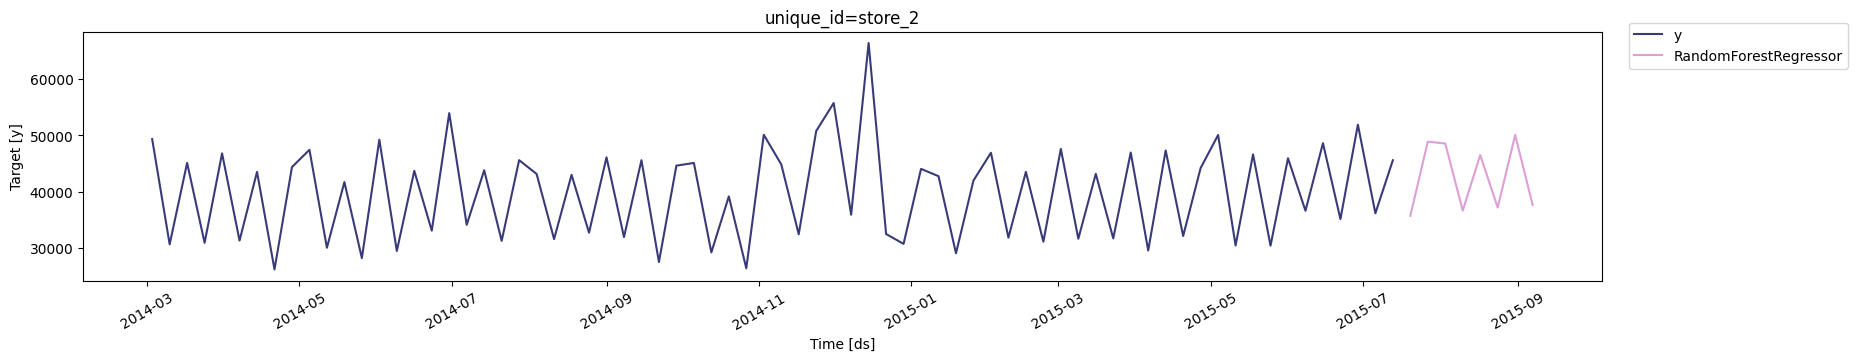

In [ ]:
# Example plot
StatsForecast.plot(df=weekly_data_filtered2, forecasts_df= fc_df, unique_ids=['store_2'], models=['AutoARIMA', 'AutoETS', 'SeasonalNaive', 'InverseMSE-Best3'], max_insample_length=72)


In [ ]:
# 1. Prepare copies of the datasets to avoid modifying originals",
weekly_sales_rf = weekly_data_encoded.copy()
weekly_future_rf = weekly_future_encoded.copy()

#3. Prepare the future dataframe for 8-week forecast (one block per store)",
future_rf = weekly_future_rf.groupby('unique_id').head(8).copy()

#4. Ensure future_rf has all columns from train_rf (except 'y')",
missing_cols = [col for col in weekly_data_filtered.columns if col not in future_rf.columns and col != 'y']
for col in missing_cols:
        future_rf[col] = 0  # or np.nan, but 0 is safer for dummies/booleans",

# 5. Ensure column order matches (except 'y')",
feature_cols = [col for col in weekly_data_filtered.columns if col != 'y']
future_rf = future_rf[feature_cols]
        

 #4. Concatenate historical and future data for feature alignment",
df_rf = pd.concat([weekly_sales_rf, future_rf], ignore_index=True)
df_rf = df_rf.sort_values(['unique_id', 'ds']).reset_index(drop=True)
        
#5. Define static features (adjust as needed for your encoding)",
static_features= ['competition_distance', 'store_type_c', 'store_type_d', 'assortment_c']

#7. Fit the model
fcst.fit(df_rf, static_features= static_features)
       
# 8. Forecast next 8 weeks for each store using the prepared future data
rf_forecast = fcst.predict(h=8)
print(rf_forecast.head())


KeyError: "['promo', 'open', 'school_holiday', 'state_holiday_a', 'state_holiday_b', 'state_holiday_c', 'seasonality', 'is_closed_week'] not in index"

In [56]:
rf_mse = metrics_df_rf['RandomForestRegressor'].mean()

In [108]:
df_new = pd.concat([rf_fc_df,fc_df_simple], ignore_index=True)
df_new.head()

,unique_id,ds,RandomForestRegressor,Naive,SeasonalNaive,SeasWA,AutoARIMA,HoltWinters,HistoricAverage,RWD
0,store_1,2015-07-20,22548.195312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,store_1,2015-07-27,29739.818359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,store_1,2015-08-03,29492.558594,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,store_1,2015-08-10,23325.892578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,store_1,2015-08-17,29095.113281,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### LSTM cross validation

In [52]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM
from sklearn.metrics import mean_squared_error

lstm_df = weekly_data_filtered.sort_values(['unique_id', 'ds'])


cutoff_dates = ['2015-05-18', '2015-06-15']
# At the end of historical data (prediction is closer to the real future)
# After each point, there are at least h=8 weeks of real data to verify

mse_list = []

for cutoff in cutoff_dates:
    train_data = lstm_df[lstm_df['ds'] <= cutoff]
    valid_data = lstm_df[(lstm_df['ds'] > cutoff)].groupby('unique_id').head(8)

    models = [LSTM(
        input_size=3, # 3 weeks
        h=8,
        max_steps=300,
        encoder_hidden_size=32,
        decoder_hidden_size=32
    )]

    nf = NeuralForecast(models=models, freq='W-MON')
    nf.fit(df=train_data)

    forecast = nf.predict()

    # 合并预测与真实
    merged = forecast.merge(valid_data[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'])


    #loss = ufl.mse(merged['y'].values, merged['LSTM'].values)
    #CHANGED LOSS THIS IS WHAT GAVE AN ERROR FOR ME
    loss = mean_squared_error(merged['y'].values, merged['LSTM'].values)
    mse_list.append(loss)
    print(f"Cutoff {cutoff} -> MSE: {loss:.4f}")

# 输出平均 MSE
print(mse_list)

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name              | Type          | Params | Mode 
------------------------------------------------------------
0 | loss              | MAE           | 0      | train
1 | padder_train      | ConstantPad1d | 0      | train
2 | scaler            | TemporalNorm  | 0      | train
3 | hist_encoder      | LSTM          | 12.9 K | train
4 | mlp_decoder       | MLP           | 1.1 K  | train
5 | upsample_sequence | Linear        | 32     | train
------------------------------------------------------------
14.0 K    Trainable params
0         Non-trainable params
14.0 K    Total params
0.056     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Epoch 74: 100%|██████████| 4/4 [00:00<00:00, 41.83it/s, v_num=18, train_loss_step=9.770, train_loss_epoch=11.40]  

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 74: 100%|██████████| 4/4 [00:00<00:00, 39.66it/s, v_num=18, train_loss_step=9.770, train_loss_epoch=11.40]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Epoch 74: 100%|██████████| 4/4 [00:00<00:00, 40.10it/s, v_num=20, train_loss_step=7.030, train_loss_epoch=7.510] 

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 74: 100%|██████████| 4/4 [00:00<00:00, 38.89it/s, v_num=20, train_loss_step=7.030, train_loss_epoch=7.510]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 4/4 [00:00<00:00, 116.80it/s]
Cutoff 2015-06-15 -> MSE: 18683712.0000
[26771926.0, 18683712.0]


In [ ]:
# 1. Prepare copies of the datasets to avoid modifying originals
weekly_sales_rf = weekly_data_encoded.copy()
weekly_future_rf = weekly_future_encoded.copy()

# 2. Prepare the future dataframe for 8-week forecast (one block per store)
future_rf = weekly_future_rf.groupby('unique_id').head(8).copy()

# 3. Ensure future_rf has all columns from weekly_data_filtered (except 'y')
missing_cols = [col for col in weekly_data_filtered.columns if col not in future_rf.columns and col != 'y']
for col in missing_cols:
    future_rf[col] = 0  # or np.nan, but 0 is safer for dummies/booleans

# 4. Ensure column order matches (except 'y')
feature_cols = [col for col in weekly_data_filtered.columns if col != 'y']
future_rf = future_rf[feature_cols]

# 5. Define static features (adjust as needed for your encoding)
static_features = ['competition_distance', 'store_type_c', 'store_type_d', 'assortment_c']

# 6. Fit the model on open weeks only
fcst.fit(weekly_data_filtered, static_features=static_features)

# 7. Forecast only for open weeks in the future data
future_rf_open = future_rf[future_rf['is_closed_week'] == 0].copy()
rf_forecast_open = fcst.predict(h=len(future_rf_open), X_df=future_rf_open, static_features=static_features)

# 8. For closed weeks, set y=0
future_rf_closed = future_rf[future_rf['is_closed_week'] == 1].copy()
if not future_rf_closed.empty:
    rf_forecast_closed = future_rf_closed[['unique_id', 'ds']].copy()
    rf_forecast_closed['RandomForestRegressor'] = 0
    rf_forecast = pd.concat([rf_forecast_open, rf_forecast_closed], ignore_index=True)
else:
    rf_forecast = rf_forecast_open

# 9. Sort forecast to match original order
rf_forecast = rf_forecast.sort_values(['unique_id', 'ds']).reset_index(drop=True)
print(rf_forecast.head())    lag_transforms={1: [RollingMean(window_size=4)]}
 )

# Fit the model
fcst.fit(weekly_data_filtered, static_features=static_ft)

# Forecast next 8 weeks for each store
rf_forecast = fcst.predict(h=8, static_features=static_ft)
print(rf_forecast.head())rt LSTM
from sklearn.metrics import mean_squared_error

lstm_df = weekly_data_filtered.sort_values(['unique_id', 'ds'])


cutoff_dates = ['2015-05-18', '2015-06-15']
# At the end of historical data (prediction is closer to the real future)
# After each point, there are at least h=8 weeks of real data to verify

mse_list = []

for cutoff in cutoff_dates:
    train_data = lstm_df[lstm_df['ds'] <= cutoff]
    valid_data = lstm_df[(lstm_df['ds'] > cutoff)].groupby('unique_id').head(8)

    models = [LSTM(
        input_size=3, # 3 weeks
        h=8,
        max_steps=300,
        encoder_hidden_size=32,
        decoder_hidden_size=32
    )]

    nf = NeuralForecast(models=models, freq='W-MON')
    nf.fit(df=train_data)

    forecast = nf.predict()

    # 合并预测与真实
    merged = forecast.merge(valid_data[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'])


    #loss = ufl.mse(merged['y'].values, merged['LSTM'].values)
    #CHANGED LOSS THIS IS WHAT GAVE AN ERROR FOR ME
    loss = mean_squared_error(merged['y'].values, merged['LSTM'].values)
    mse_list.append(loss)
    print(f"Cutoff {cutoff} -> MSE: {loss:.4f}")

# 输出平均 MSE
print(mse_list)


Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name              | Type          | Params | Mode 
------------------------------------------------------------
0 | loss              | MAE           | 0      | train
1 | padder_train      | ConstantPad1d | 0      | train
2 | scaler            | TemporalNorm  | 0      | train
3 | hist_encoder      | LSTM          | 12.9 K | train
4 | mlp_decoder       | MLP           | 1.1 K  | train
5 | upsample_sequence | Linear        | 32     | train
------------------------------------------------------------
14.0 K    Trainable params
0         Non-trainable params
14.0 K    Total params
0.056     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode

  | Name              | Type          | Params | Mode 
-------

Epoch 74: 100%|██████████| 4/4 [00:00<00:00, 45.74it/s, v_num=14, train_loss_step=9.770, train_loss_epoch=11.40] 

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 74: 100%|██████████| 4/4 [00:00<00:00, 43.44it/s, v_num=14, train_loss_step=9.770, train_loss_epoch=11.40]



GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Epoch 74: 100%|██████████| 4/4 [00:00<00:00, 33.07it/s, v_num=16, train_loss_step=7.030, train_loss_epoch=7.510] 

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 74: 100%|██████████| 4/4 [00:00<00:00, 28.96it/s, v_num=16, train_loss_step=7.030, train_loss_epoch=7.510]



GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 4/4 [00:00<00:00, 116.52it/s]
Cutoff 2015-06-15 -> MSE: 18683712.0000
[26771926.0, 18683712.0]

Cutoff 2015-06-15 -> MSE: 18683712.0000
[26771926.0, 18683712.0]


# Aggregate cross-validation results for all models and select best per store for MSE and MAPE
# Assumes 'metrics_all' DataFrame exists with columns: ['unique_id', 'metric', 'method', 'value']

# Pivot to get all model metrics per store
metrics_pivot = metrics_all.pivot_table(index=['unique_id', 'metric'], columns='method', values='value')

# For each store, find best model and value for MSE and MAPE
best_mse_model = metrics_pivot.loc[(slice(None), 'mse'), :].idxmin(axis=1)
best_mse_value = metrics_pivot.loc[(slice(None), 'mse'), :].min(axis=1)
best_mape_model = metrics_pivot.loc[(slice(None), 'mape'), :].idxmin(axis=1)
best_mape_value = metrics_pivot.loc[(slice(None), 'mape'), :].min(axis=1)

# Build result DataFrame
best_models_summary = pd.DataFrame({
    'unique_id': best_mse_model.index.get_level_values('unique_id'),
    'best_model_mse': best_mse_model.values,
    'best_mse': best_mse_value.values,
    'best_model_mape': best_mape_model.values,
    'best_mape': best_mape_value.values
})

# Show summary
best_models_summary.head()

In [53]:
# 1. Convert Random Forest and LSTM results to the same format as metrics_all
rf_mse_long = rf_mse[['unique_id', 'rf_mse']].rename(columns={'rf_mse': 'value'})
rf_mse_long['method'] = 'RandomForestRegressor'
rf_mse_long['metric'] = 'mse'

rf_mape_long = rf_mape[['unique_id', 'rf_mape']].rename(columns={'rf_mape': 'value'})
rf_mape_long['method'] = 'RandomForestRegressor'
rf_mape_long['metric'] = 'mape'

lstm_mse_long = lstm_mse_df.rename(columns={'lstm_mse': 'value'})
lstm_mse_long['method'] = 'LSTM'
lstm_mse_long['metric'] = 'mse'

# 2. Concatenate all results
metrics_all_extended = pd.concat([
    metrics_all,
    rf_mse_long[['unique_id', 'metric', 'method', 'value']],
    rf_mape_long[['unique_id', 'metric', 'method', 'value']],
    lstm_mse_long[['unique_id', 'metric', 'method', 'value']]
], ignore_index=True)

# 3. Now run the summary code on metrics_all_extended
metrics_pivot = metrics_all_extended.pivot_table(index=['unique_id', 'metric'], columns='method', values='value')

best_mse_model = metrics_pivot.loc[(slice(None), 'mse'), :].idxmin(axis=1)
best_mse_value = metrics_pivot.loc[(slice(None), 'mse'), :].min(axis=1)
best_mape_model = metrics_pivot.loc[(slice(None), 'mape'), :].idxmin(axis=1)
best_mape_value = metrics_pivot.loc[(slice(None), 'mape'), :].min(axis=1)

best_models_summary = pd.DataFrame({
    'unique_id': best_mse_model.index.get_level_values('unique_id'),
    'best_model_mse': best_mse_model.values,
    'best_mse': best_mse_value.values,
    'best_model_mape': best_mape_model.values,
    'best_mape': best_mape_value.values
})

best_models_summary.head()

,unique_id,best_model_mse,best_mse,best_model_mape,best_mape
0,store_1,RandomForestRegressor,3.441245e+06,RandomForestRegressor,0.063061
1,store_10,RandomForestRegressor,7.066682e+06,RandomForestRegressor,0.052753
2,store_11,RandomForestRegressor,3.313164e+07,RandomForestRegressor,0.108659
3,store_12,RandomForestRegressor,1.471157e+07,RandomForestRegressor,0.087048
4,store_13,RandomForestRegressor,1.757956e+07,RandomForestRegressor,0.126662


In [ ]:
# ✅ Final Forecast Generation Using Best Model Per Store (All Models)

import numpy as np
from sklearn.metrics import mean_squared_error
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM
# assuming AutoARIMA, Ensemble, etc., are imported similarly
# e.g. from neuralforecast.models import AutoARIMA, Ensemble

# 1. Prepare the full dataset
full_df = weekly_data_filtered.sort_values(['unique_id', 'ds'])

# 2. Fit & forecast each model on full data
model_forecasts = {}

# 2a. LSTM
lstm_mod = LSTM(input_size=3, h=8, max_steps=300, encoder_hidden_size=32, decoder_hidden_size=32)
nf = NeuralForecast(models=[lstm_mod], freq='W-MON')
nf.fit(df=full_df)
df_lstm = nf.predict().rename(columns={'LSTM': 'lstm_pred'})
model_forecasts['LSTM'] = df_lstm

# 2b. Random Forest
# Ensure rf_forecast exists or compute it similarly
if 'rf_pred' not in globals():
    raise ValueError("Please compute rf_pred before this step.")
model_forecasts['Random Forest'] = rf_pred.rename(columns={rf_pred.columns[-1]: 'rf_pred'})

# 2c. AutoARIMA (if used)
if 'autoarima_pred' in globals():
    model_forecasts['AutoARIMA'] = autoarima_pred.rename(columns={autoarima_pred.columns[-1]: 'autoarima_pred'})

# 2d. Ensemble or other models
if 'ensemble_pred' in globals():
    model_forecasts['Ensemble'] = ensemble_pred.rename(columns={ensemble_pred.columns[-1]: 'ensemble_pred'})

# 3. Merge all forecasts
combined = full_df[['unique_id', 'ds']].drop_duplicates()
for model_name, df_pred in model_forecasts.items():
    combined = combined.merge(df_pred, on=['unique_id', 'ds'], how='left')

# 4. Merge in best model per store
combined = combined.merge(
    best_models[['unique_id', 'best_model-mse']],
    on='unique_id',
    how='left'
)

# 5. Choose final forecast based on best_model-mse
def choose_forecast(row):
    model = row['best_model-mse']
    col = model.lower().replace(" ", "_") + '_pred'
    return row.get(col, np.nan)

combined['final_forecast'] = combined.apply(choose_forecast, axis=1)

# ✅ Final Output
final_forecast = combined[['unique_id', 'ds', 'final_forecast']].sort_values(['unique_id', 'ds'])
print(final_forecast.head(16))


In [ ]:
# Sales forecast for next 8 weeks using the best model per store
# User selects error metric: 'mse' or 'mape'

# User selection
error_metric = 'mse'  # Change to 'mape' to use MAPE for model selection

# Prepare best model column name
if error_metric == 'mse':
    best_model_col = 'best_model_mse'
else:
    best_model_col = 'best_model_mape'

# Dictionary mapping model names to forecast DataFrames
model_forecast_dict = {
    'Naive': fc_df_naive,
    'RandomWalkWithDrift': fc_df_rwd,
    'SeasonalNaive': fc_df_seasonalnaive,
    'HoltWinters': fc_df_holtwinters,
    'AutoARIMA': fc_df_autoarima,
    'RandomForestRegressor': fc_df_rf,
    'LSTM': fc_df_lstm,
    'Ensemble': fc_df_ensemble
}

# Prepare forecast DataFrame
all_forecasts = []

for idx, row in best_models_summary.iterrows():
    store_id = row['unique_id']
    best_model = row[best_model_col]

    # Select forecast DataFrame for the model using the dictionary
    fc_df = model_forecast_dict.get(best_model)
    if fc_df is None:
        continue  # Skip if model not found

    # Get forecast for this store
    store_fc = fc_df[fc_df['unique_id'] == store_id].copy()
    store_fc['selected_model'] = best_model
    all_forecasts.append(store_fc)

# Concatenate all forecasts
final_forecast = pd.concat(all_forecasts, ignore_index=True)

# Show the first few rows
final_forecast.head()

In [94]:
filtered = future_df[future_df['open'] == 0]
print(filtered)

Empty DataFrame
Columns: [unique_id, ds, promo, open, school_holiday, competition_distance, state_holiday_a, state_holiday_b, state_holiday_c, is_closed_week, store_type_c, store_type_d, assortment_c]
Index: []
